# Healthcare staffing pipeline - EDA
## Master Dataset: PBJ Daily Nurse Staffing Q2 2024
**Purpose:** Understand schema, grain, data quality, and relationships before designing the pipeline architecture.
**Output:** Data dictionary and pipeline design decisions in /docs

In [211]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

# ── Environment ───────────────────────────────────────────────────────────────
load_dotenv()  # reads your .env file

DATA_PATH = Path(os.getenv("LOCAL_DATA_PATH"))
MASTER_FILE = DATA_PATH / "PBJ_Daily_Nurse_Staffing_Q2_2024.csv"

# -- Verify paths exists before loading ------------------------------------------
print(f"Data path exists: {DATA_PATH.exists()}")
print(f"Master file exists: {MASTER_FILE.exists()}")
print(f"Files in data dictionary: {len(list(DATA_PATH.glob('*.csv')))}")

Data path exists: True
Master file exists: True
Files in data dictionary: 22


## Section 2: Master File — First Look
Goal: Understand shape, data types, and basic structure

In [212]:
# ── Load master file ──────────────────────────────────────────────────────────
# low_memory=False prevents pandas from guessing column types mid-file
# which can cause mixed-type columns on large CSVs

# Try loading with Latin-1 encoding
df = pd.read_csv(MASTER_FILE, low_memory=False, encoding='ISO-8859-1')
# -- Shape ----------------------------------------------------------------------
print("=" * 60)
print("SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# ── Shape ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("COLUMN NAMES, TYPES & SAMPLE VALUE")
print("=" * 60)
for col in df.columns:
    sample = df[col].dropna().iloc[0] if df[col].notna().any() else "ALL NULL"
    print(f"{col:<30} {str(df[col].dtype):<12} sample: {sample}")

#--Preview -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
df.head(3)

SHAPE
Rows: 1325324
Columns: 33

COLUMN NAMES, TYPES & SAMPLE VALUE
PROVNUM                        object       sample: 015009
PROVNAME                       object       sample: BURNS NURSING HOME, INC.
CITY                           object       sample: RUSSELLVILLE
STATE                          object       sample: AL
COUNTY_NAME                    object       sample: Franklin
COUNTY_FIPS                    int64        sample: 59
CY_Qtr                         object       sample: 2024Q2
WorkDate                       int64        sample: 20240401
MDScensus                      int64        sample: 51
Hrs_RNDON                      float64      sample: 10.77
Hrs_RNDON_emp                  float64      sample: 10.77
Hrs_RNDON_ctr                  float64      sample: 0.0
Hrs_RNadmin                    float64      sample: 10.4
Hrs_RNadmin_emp                float64      sample: 10.4
Hrs_RNadmin_ctr                float64      sample: 0.0
Hrs_RN                         float64     

,PROVNUM,PROVNAME,CITY,STATE,COUNTY_NAME,COUNTY_FIPS,CY_Qtr,WorkDate,MDScensus,Hrs_RNDON,...,Hrs_LPN_ctr,Hrs_CNA,Hrs_CNA_emp,Hrs_CNA_ctr,Hrs_NAtrn,Hrs_NAtrn_emp,Hrs_NAtrn_ctr,Hrs_MedAide,Hrs_MedAide_emp,Hrs_MedAide_ctr
0,015009,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,Franklin,59,2024Q2,20240401,51,10.77,...,0.0,160.08,160.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,015009,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,Franklin,59,2024Q2,20240402,52,8.43,...,0.0,135.95,135.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,015009,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,Franklin,59,2024Q2,20240403,53,11.13,...,0.0,150.31,150.31,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Section 3: Grain Confirmation
Goal: Confirm the grain is PROVNUM x WorkDate (one row per provider per day)

In [ ]:
# -- Grain Confirmation --------------------------------------
total_rows = len(df)
unique_combos = df.groupby(['PROVNUM','WorkDate']).ngroups
print("=" * 60)
print("GRAIN CONFIRMATION: PROVNUM + WorkDate")
print("=" * 60)
print(f"Total Rows:              {total_rows:,}")
print(f"Unique PROVNUM+WorkDate: {unique_combos:,}")
print(f"Grain is unique:         {total_rows==unique_combos}")

#  -- If Duplicates exist, inspect them -------------------------
if total_rows != unique_combos:
    dupes = df[df.duplicated(subset=['PROVNUM', 'WorkDate'], keep=False)]
    print(f"\nDuplicate row found: {len(dupes):,}")
    print("\nSample Suplicates:")
    print(dupes.sort_values(['PROVNUM', 'WorkDate']).head(6))

# -- Date range ---------------------------------------------------
print("\n" + "=" * 60)
print("Date Range")
print("=" * 60)
print(f"Min WorkDate: {df['WorkDate'].min()}")
print(f"Max WorkDate: {df['WorkDate'].max()}")
print(f"Unique dates: {df['WorkDate'].nunique()}")

# ── Provider count ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PROVIDER COVERAGE")
print("=" * 60)
print(f"Unique providers (PROVNUM): {df['PROVNUM'].nunique():,}")
print(f"Unique states:              {df['STATE'].nunique()}")
print(f"Expected rows if complete:  {df['PROVNUM'].nunique() * df['WorkDate'].nunique():,}")
print(f"Actual rows:                {total_rows:,}")
print(f"Coverage %:                 {(total_rows / (df['PROVNUM'].nunique() * df['WorkDate'].nunique()) * 100):.1f}%")

GRAIN CONFIRMATION: PROVNUM + WorkDate
Total Rows:              1,325,324
Unique PROVNUM+WorkDate: 1,325,324
Grain is unique:         True

Date Range
Min WorkDate: 20240401
Max WorkDate: 20240630
Unique dates: 91

PROVIDER COVERAGE
Unique providers (PROVNUM): 14,564
Unique states:              52
Expected rows if complete:  1,325,324
Actual rows:                1,325,324
Coverage %:                 100.0%


## Section4: Missing Value & Quality Analysis

In [214]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# -- Null Analysis --------------------------------------------
print("=" * 60)
print("NULL ANALYSIS")
print("=" * 60)
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).query('null_count>0').sort_values('null_pct', ascending=False)

if null_df.empty:
    print("✅ No null values found in any column")
else:
    print(null_df.to_string())

# -- Zero Analysis (hours columns only)
print("\n" + "=" * 60)
print("ZERO VALUE ANALYSIS - HOURS COLUMN")
print("=" * 60)
hrs_cols = [c for c in df.columns if c.startswith('Hrs')]
zero_df = pd.DataFrame({
    'zero_count': [(df[c] == 0).sum() for c in hrs_cols],
    'zero_pct': [(df[c] == 0).sum() / len(df) * 100 for c in hrs_cols]
}, index = hrs_cols)
print(zero_df)
# -- MDScensus Anomalies --------------------------------------
print("\n" + "=" * 60)
print("MDScensus Anomalies")
print("=" * 60)
hrs_total = df[hrs_cols].sum(axis=1)
print(f"Zero census rows                     {(df['MDScensus'] == 0).sum():,}")
print(f"Negative census rows                 {(df['MDScensus'] < 0).sum():,}")
print(f"Rows with zero census but hours > 0: {len(df[(df['MDScensus'] == 0) & (hrs_total>0)])}")


NULL ANALYSIS
✅ No null values found in any column

ZERO VALUE ANALYSIS - HOURS COLUMN
                  zero_count   zero_pct
Hrs_RNDON             495886  37.416209
Hrs_RNDON_emp         509270  38.426075
Hrs_RNDON_ctr        1309994  98.843302
Hrs_RNadmin           579234  43.705086
Hrs_RNadmin_emp       590468  44.552728
Hrs_RNadmin_ctr      1287585  97.152470
Hrs_RN                 89326   6.739937
Hrs_RN_emp            112569   8.493697
Hrs_RN_ctr           1111961  83.901069
Hrs_LPNadmin          753768  56.874244
Hrs_LPNadmin_emp      757347  57.144291
Hrs_LPNadmin_ctr     1317411  99.402938
Hrs_LPN                32697   2.467095
Hrs_LPN_emp            46509   3.509255
Hrs_LPN_ctr           984259  74.265538
Hrs_CNA                 5785   0.436497
Hrs_CNA_emp             8483   0.640070
Hrs_CNA_ctr           933776  70.456432
Hrs_NAtrn            1075892  81.179546
Hrs_NAtrn_emp        1077825  81.325397
Hrs_NAtrn_ctr        1322500  99.786920
Hrs_MedAide           916991  69.

## Section 5: Staffing Hours Distribution
Goal: Understand the distribution of key hours columns
and identify outliers that need handling in Silver layer

DESCRIPTIVE STATISTICS — KEY HOURS COLUMNS
           Hrs_RN     Hrs_LPN     Hrs_CNA   Hrs_RNDON  Hrs_MedAide
count  1325324.00  1325324.00  1325324.00  1325324.00   1325324.00
mean        34.80       66.17      173.79        5.20         8.58
std         35.32       49.82      115.16        4.39        17.86
min          0.00        0.00        0.00        0.00         0.00
25%         13.25       32.60       98.57        0.00         0.00
50%         25.75       56.81      150.62        8.00         0.00
75%         45.25       88.50      220.00        8.00        11.31
max        915.98    13946.25     1758.10      103.96       429.80

OUTLIER DETECTION (IQR METHOD)
Hrs_RN               upper bound:      93.25  outliers: 64,542  (4.87%)
Hrs_LPN              upper bound:     172.35  outliers: 42,389  (3.20%)
Hrs_CNA              upper bound:     402.14  outliers: 49,416  (3.73%)
Hrs_RNDON            upper bound:      20.00  outliers:  2,881  (0.22%)
Hrs_MedAide          upper bound: 

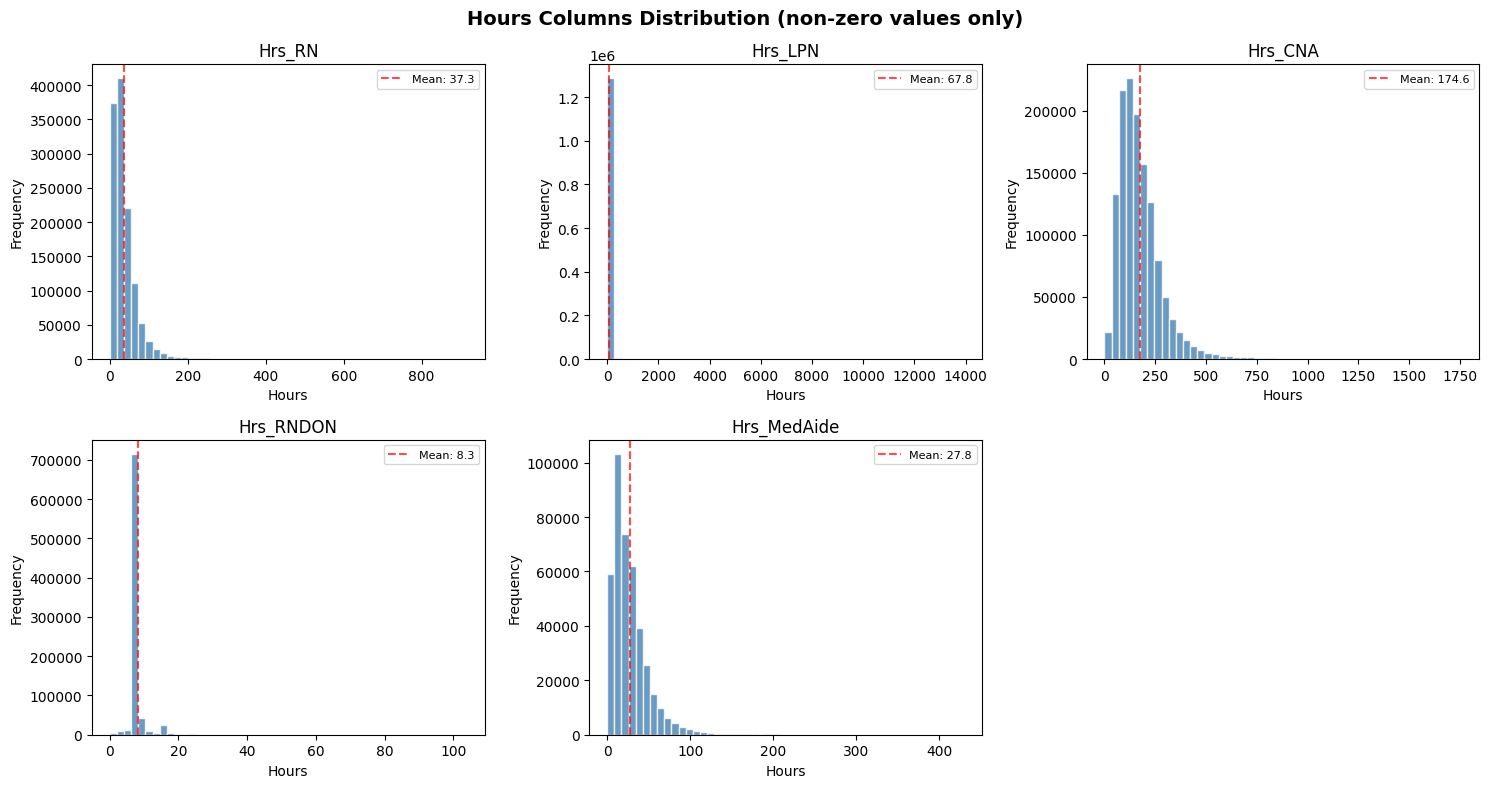

Chart saved to docs/eda_hours_distribution.png


In [124]:
# ── Key hours columns to analyze ──────────────────────────────────────────────
key_cols = ['Hrs_RN', 'Hrs_LPN', 'Hrs_CNA', 'Hrs_RNDON', 'Hrs_MedAide']

print("=" * 60)
print("DESCRIPTIVE STATISTICS — KEY HOURS COLUMNS")
print("=" * 60)
print(df[key_cols].describe().round(2).to_string())

# ── Outlier Detection using IQR ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 60)
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[df[col] > upper_bound]
    print(f"{col:<20} upper bound: {upper_bound:>10.2f}  "
          f"outliers: {len(outliers):>6,}  "
          f"({len(outliers)/len(df)*100:.2f}%)")

# ── Visualize distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Hours Columns Distribution (non-zero values only)',
             fontsize=14, fontweight='bold')

for idx, col in enumerate(key_cols):
    ax = axes[idx // 3][idx % 3]
    non_zero = df[df[col] > 0][col]
    ax.hist(non_zero, bins=50, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Frequency')
    ax.axvline(non_zero.mean(), color='red',
               linestyle='--', alpha=0.7, label=f'Mean: {non_zero.mean():.1f}')
    ax.legend(fontsize=8)

# hide the 6th subplot (we only have 5 cols)
axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/eda_hours_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/eda_hours_distribution.png")

## Section 6: Employment Type Analysis
Goal: Understand the split between employed vs contracted staff
This drives the "contract ratio" metric — a key operational risk indicator

EMPLOYED vs CONTRACT STAFF — TOTAL HOURS
   role  employed_hrs  contract_hrs  contract_pct
    LPN    79571107.0     8128794.0          9.27
     RN    42397420.0     3726399.0          8.08
    CNA   214184635.0    16144431.0          7.01
MedAide    11084087.0      284975.0          2.51
  RNDON     6758241.0      127992.0          1.86
  NAtrn     5648620.0       69034.0          1.21


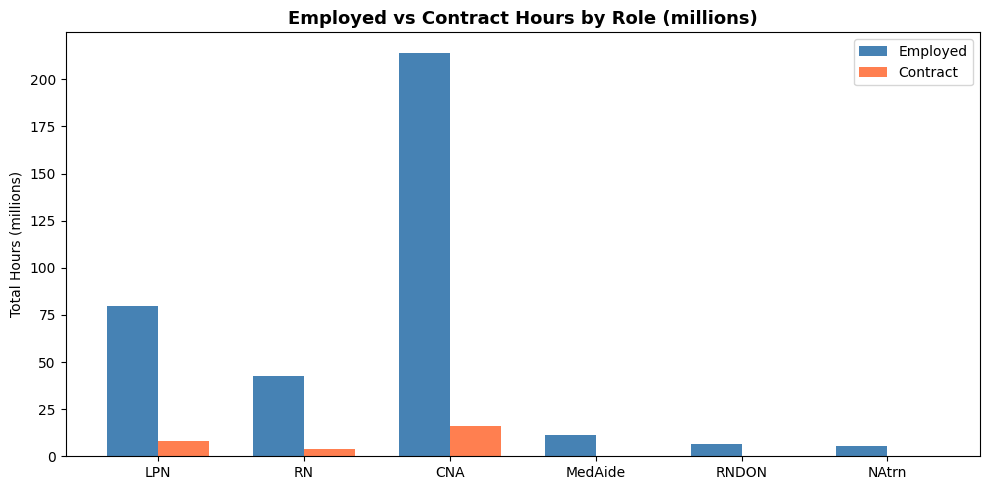

Chart saved to docs/eda_emp_vs_contract.png


In [145]:
# ── Build employed vs contract summary ────────────────────────────────────────
print("=" * 60)
print("EMPLOYED vs CONTRACT STAFF — TOTAL HOURS")
print("=" * 60)

role_map = {
    'RN':      ('Hrs_RN_emp',      'Hrs_RN_ctr'),
    'LPN':     ('Hrs_LPN_emp',     'Hrs_LPN_ctr'),
    'CNA':     ('Hrs_CNA_emp',     'Hrs_CNA_ctr'),
    'RNDON':   ('Hrs_RNDON_emp',   'Hrs_RNDON_ctr'),
    'MedAide': ('Hrs_MedAide_emp', 'Hrs_MedAide_ctr'),
    'NAtrn':   ('Hrs_NAtrn_emp',   'Hrs_NAtrn_ctr'),
}

emp_ctr_summary = []
for role, (emp_col, ctr_col) in role_map.items():
    total_emp = df[emp_col].sum()
    total_ctr = df[ctr_col].sum()
    total     = total_emp + total_ctr
    ctr_pct   = (total_ctr / total * 100) if total > 0 else 0
    emp_ctr_summary.append({
        'role':         role,
        'employed_hrs': round(total_emp, 0),
        'contract_hrs': round(total_ctr, 0),
        'contract_pct': round(ctr_pct, 2)
    })

emp_df = pd.DataFrame(emp_ctr_summary).sort_values('contract_pct', ascending=False)
print(emp_df.to_string(index=False))

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(emp_df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], emp_df['employed_hrs'] / 1e6,
               width, label='Employed', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], emp_df['contract_hrs'] / 1e6,
               width, label='Contract', color='coral')
ax.set_title('Employed vs Contract Hours by Role (millions)',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(emp_df['role'])
ax.set_ylabel('Total Hours (millions)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/eda_emp_vs_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/eda_emp_vs_contract.png")

## Section 7: Geographic Distribution
Goal: Understand provider and patient distribution across states
This informs S3 partitioning strategy (partition by STATE)

PROVIDERS PER STATE (Top 15)
STATE
TX    1168
CA    1142
OH     922
FL     691
IL     673
PA     663
NY     597
IN     509
MO     475
MI     421
NC     409
IA     393
GA     352
NJ     345
MA     341

AVERAGE DAILY CENSUS PER STATE (Top 15)
STATE
NY    163.5
DC    119.8
NJ    117.2
FL    106.1
MD    105.5
PA     99.9
CT     99.8
VA     97.4
AL     95.9
MA     95.2
RI     94.9
LA     90.4
IL     90.3
NV     88.7
SC     88.6

TOTAL STAFFING HOURS PER STATE (Top 15)
STATE
CA    76.06
NY    63.81
TX    51.46
FL    50.77
OH    43.84
PA    43.75
IL    36.00
NJ    26.76
MI    23.94
IN    23.31
NC    22.50
MA    21.99
MO    19.97
GA    19.44
VA    17.88
(values in millions of hours)


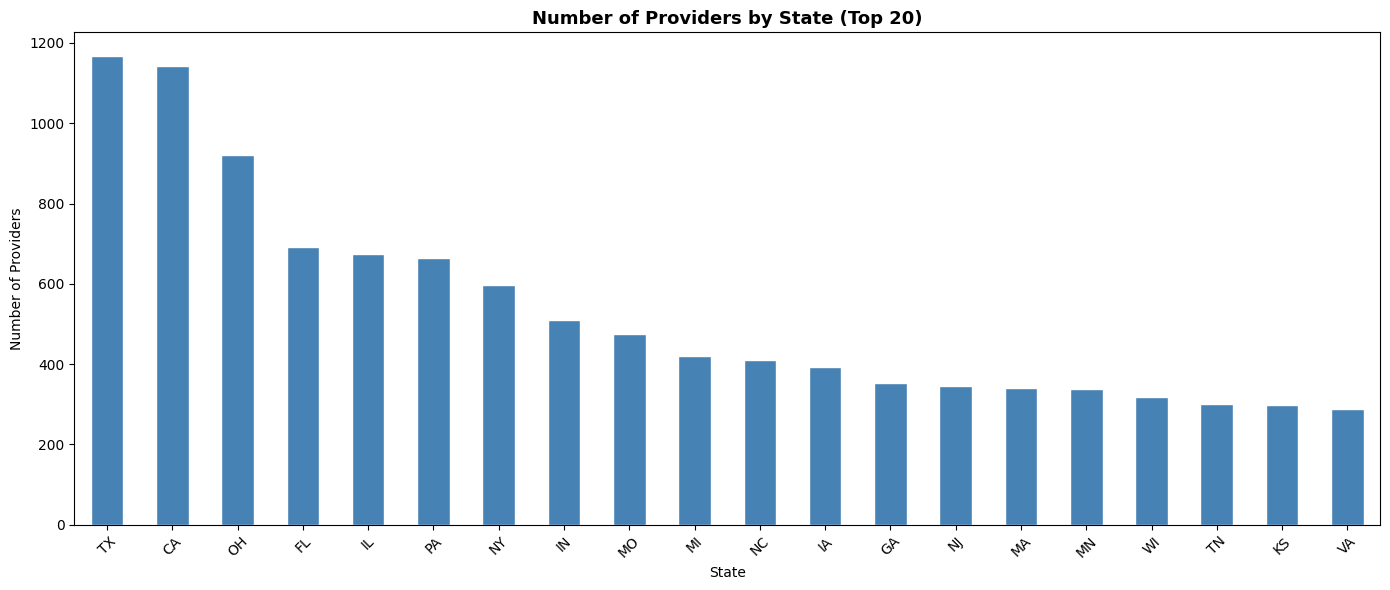

Chart saved to docs/eda_providers_per_state.png


In [165]:
# ── Providers per state ───────────────────────────────────────────────────────
print("=" * 60)
print("PROVIDERS PER STATE (Top 15)")
print("=" * 60)
providers_per_state = (df.groupby('STATE')['PROVNUM']
                         .nunique()
                         .sort_values(ascending=False))
print(providers_per_state.head(15).to_string())

# ── Average census per state ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("AVERAGE DAILY CENSUS PER STATE (Top 15)")
print("=" * 60)
avg_census = (df.groupby('STATE')['MDScensus']
                .mean()
                .round(1)
                .sort_values(ascending=False))
print(avg_census.head(15).to_string())

# ── Total staffing hours per state ────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOTAL STAFFING HOURS PER STATE (Top 15)")
print("=" * 60)
total_hrs_col = df[hrs_cols].sum(axis=1)
state_hrs = (df.assign(total_hours=total_hrs_col)
               .groupby('STATE')['total_hours']
               .sum()
               .sort_values(ascending=False))
print((state_hrs.head(15) / 1e6).round(2).to_string())
print("(values in millions of hours)")

# ── Visualize providers per state ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
providers_per_state.head(20).plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Number of Providers by State (Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Providers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../docs/eda_providers_per_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/eda_providers_per_state.png")

## Section 8: Nurse-to-Patient Ratio Preview
Goal: Calculate a raw preview of the key metric before
any pipeline work — validates that the metric is calculable
and gives us expected value ranges

NURSE HOURS PER PATIENT PER DAY — RAW PREVIEW
Mean:   3.37 hrs/patient/day
Median: 3.25 hrs/patient/day
Min:    0.00
Max:    193.08

Rows excluded (census=0): 320

AVERAGE NURSE HRS PER PATIENT BY STATE (Top & Bottom 5)
Top 5 (highest staffing):
STATE
AK    6.06
PR    4.58
DC    4.54
OR    4.21
HI    4.12

Bottom 5 (lowest staffing):
STATE
NM    3.02
IN    2.87
OK    2.79
TX    2.74
MO    2.48


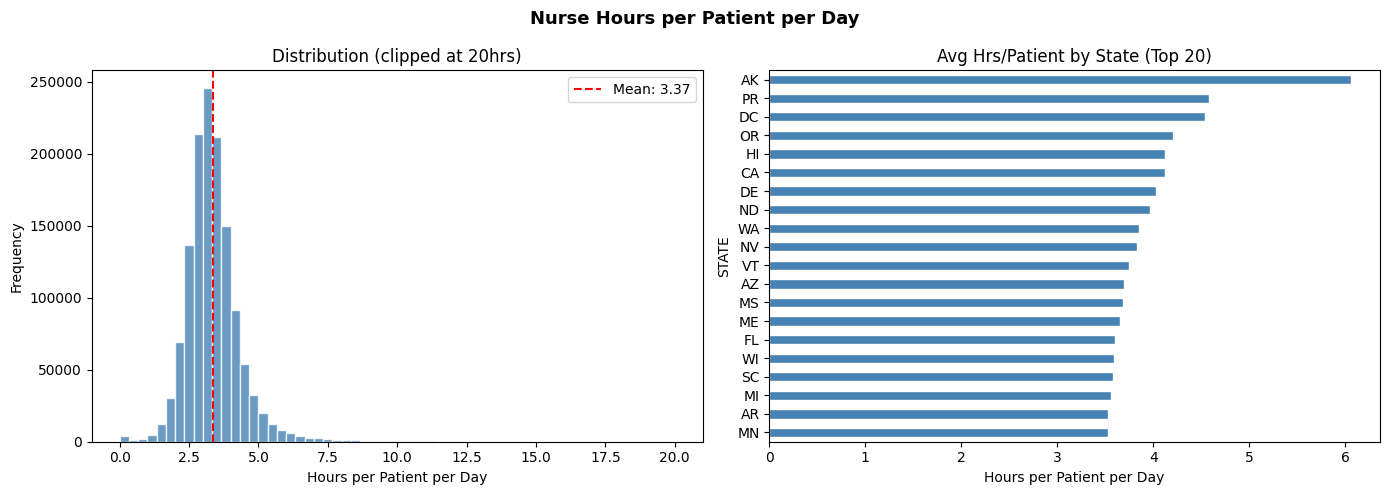

Chart saved to docs/eda_nurse_patient_ratio.png


In [179]:
# ── Calculate raw nurse-to-patient ratio ──────────────────────────────────────
# Only calculate where census > 0 to avoid division by zero
df_valid = df[df['MDScensus'] > 0].copy()

df_valid['total_nursing_hrs'] = (
    df_valid['Hrs_RN'] +
    df_valid['Hrs_LPN'] +
    df_valid['Hrs_CNA']
)

# Nurse hours per patient per day
df_valid['hrs_per_patient'] = (
    df_valid['total_nursing_hrs'] / df_valid['MDScensus']
)

print("=" * 60)
print("NURSE HOURS PER PATIENT PER DAY — RAW PREVIEW")
print("=" * 60)
print(f"Mean:   {df_valid['hrs_per_patient'].mean():.2f} hrs/patient/day")
print(f"Median: {df_valid['hrs_per_patient'].median():.2f} hrs/patient/day")
print(f"Min:    {df_valid['hrs_per_patient'].min():.2f}")
print(f"Max:    {df_valid['hrs_per_patient'].max():.2f}")
print(f"\nRows excluded (census=0): {len(df) - len(df_valid):,}")

# ── By state ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("AVERAGE NURSE HRS PER PATIENT BY STATE (Top & Bottom 5)")
print("=" * 60)
state_ratio = (df_valid.groupby('STATE')['hrs_per_patient']
                       .mean()
                       .round(2)
                       .sort_values(ascending=False))
print("Top 5 (highest staffing):")
print(state_ratio.head(5).to_string())
print("\nBottom 5 (lowest staffing):")
print(state_ratio.tail(5).to_string())

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Nurse Hours per Patient per Day',
             fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(
    df_valid['hrs_per_patient'].clip(upper=20),
    bins=60, color='steelblue', edgecolor='white', alpha=0.8
)
axes[0].axvline(df_valid['hrs_per_patient'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {df_valid['hrs_per_patient'].mean():.2f}")
axes[0].set_xlabel('Hours per Patient per Day')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (clipped at 20hrs)')
axes[0].legend()

# By state (top 20)
state_ratio.head(20).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Avg Hrs/Patient by State (Top 20)')
axes[1].set_xlabel('Hours per Patient per Day')
plt.tight_layout()
plt.savefig('../docs/eda_nurse_patient_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/eda_nurse_patient_ratio.png")

## Section 9: WorkDate Casting & Time Trends
Goal: Cast WorkDate to proper date type and analyze
trends over Q2 2024 — validates time-series analysis is possible

WORKDATE CASTING
Original:  20240401 (int64)
Converted: 2024-04-01 00:00:00 (datetime64)
Date range: 2024-04-01 → 2024-06-30

MONTHLY STAFFING TRENDS
            avg_census  avg_hrs_per_patient     total_hrs
month_name                                               
April            83.34                 3.36  1.196295e+08
May              83.40                 3.37  1.243182e+08
June             83.56                 3.37  1.201970e+08


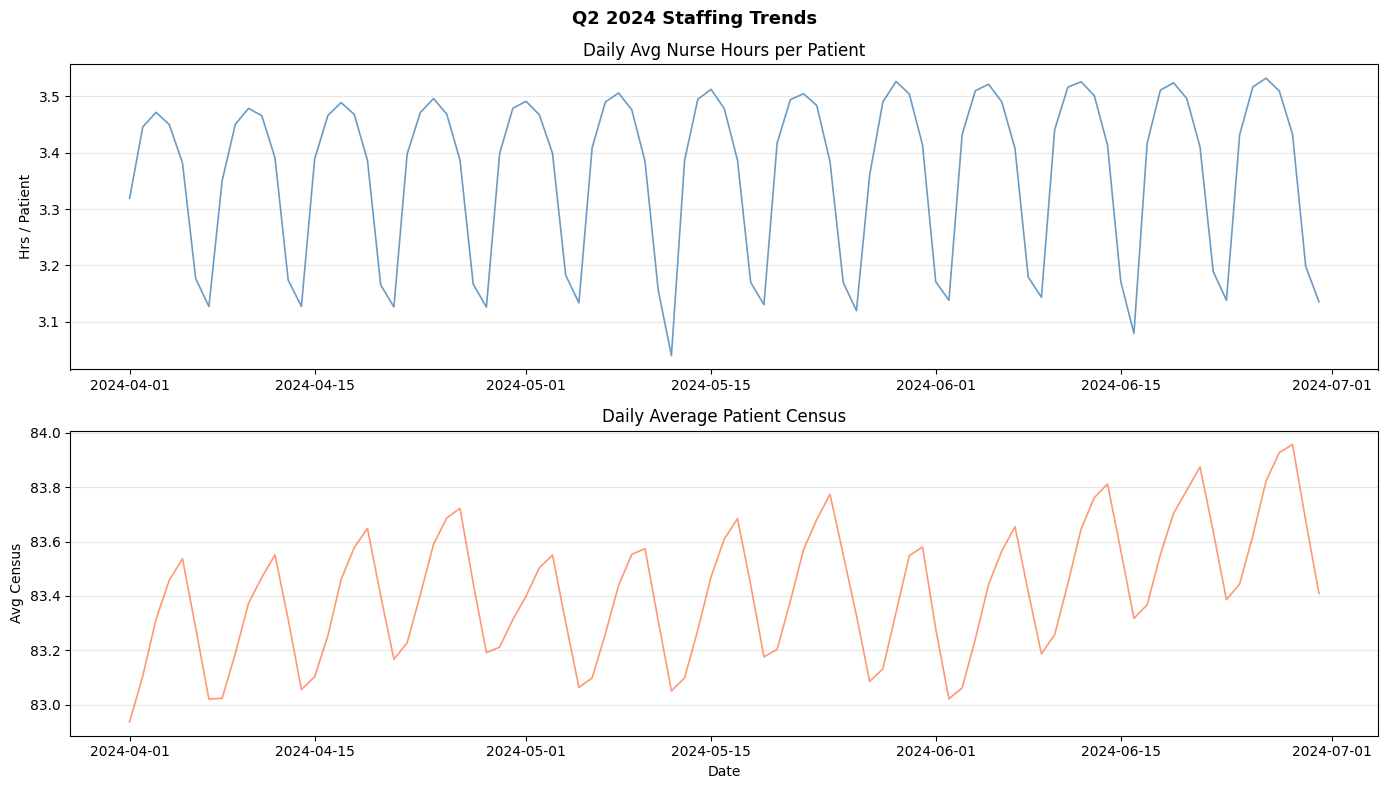

Chart saved to docs/eda_time_trends.png


In [210]:
# ── Cast WorkDate ─────────────────────────────────────────────────────────────
df['work_date'] = pd.to_datetime(df['WorkDate'].astype(str), format='%Y%m%d')
df['month']     = df['work_date'].dt.month
df['month_name'] = df['work_date'].dt.strftime('%B')
df['week']      = df['work_date'].dt.isocalendar().week

print("=" * 60)
print("WORKDATE CASTING")
print("=" * 60)
print(f"Original:  {df['WorkDate'].iloc[0]} (int64)")
print(f"Converted: {df['work_date'].iloc[0]} (datetime64)")
print(f"Date range: {df['work_date'].min().date()} → {df['work_date'].max().date()}")

# ── Monthly trends ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MONTHLY STAFFING TRENDS")
print("=" * 60)
df_valid2 = df[df['MDScensus'] > 0].copy()
df_valid2['total_nursing_hrs'] = (
    df_valid2['Hrs_RN'] +
    df_valid2['Hrs_LPN'] +
    df_valid2['Hrs_CNA']
)
df_valid2['hrs_per_patient'] = (
    df_valid2['total_nursing_hrs'] / df_valid2['MDScensus']
)

monthly = (df_valid2.groupby('month_name')
                    .agg(
                        avg_census=('MDScensus', 'mean'),
                        avg_hrs_per_patient=('hrs_per_patient', 'mean'),
                        total_hrs=('total_nursing_hrs', 'sum')
                    )
                    .round(2))
# Sort by month order
month_order = ['April', 'May', 'June']
monthly = monthly.reindex(month_order)
print(monthly.to_string())

# ── Weekly trend chart ────────────────────────────────────────────────────────
weekly = (df_valid2.groupby('work_date')['hrs_per_patient']
                   .mean()
                   .reset_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Q2 2024 Staffing Trends', fontsize=13, fontweight='bold')

# Daily avg hrs per patient
axes[0].plot(weekly['work_date'], weekly['hrs_per_patient'],
             color='steelblue', linewidth=1.2, alpha=0.8)
axes[0].set_title('Daily Avg Nurse Hours per Patient')
axes[0].set_ylabel('Hrs / Patient')
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.3)

# Daily avg census
daily_census = df.groupby('work_date')['MDScensus'].mean()
axes[1].plot(daily_census.index, daily_census.values,
             color='coral', linewidth=1.2, alpha=0.8)
axes[1].set_title('Daily Average Patient Census')
axes[1].set_ylabel('Avg Census')
axes[1].set_xlabel('Date')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/eda_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/eda_time_trends.png")

## Section 10: Key Findings Summary
This section documents all findings that drive pipeline
and architecture decisions downstream

In [215]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           MASTER FILE EDA — KEY FINDINGS SUMMARY                    ║
║           PBJ_Daily_Nurse_Staffing_Q2_2024.csv                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STRUCTURE                                                           ║
║  ├── Rows:        1,325,324                                          ║
║  ├── Columns:     33                                                 ║
║  ├── Grain:       PROVNUM × WorkDate (confirmed 100% unique)         ║
║  ├── Date range:  2024-04-01 → 2024-06-30 (91 days, Q2 2024)        ║
║  ├── Providers:   14,564 unique facilities                           ║
║  ├── States:      52 (50 states + DC + PR)                           ║
║  └── Coverage:    100% (every provider reported every day)           ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATA TYPE ISSUES → Fix in Silver Layer                              ║
║  ├── WorkDate:  int64 (20240401) → cast to DATE (%Y%m%d)            ║
║  ├── PROVNUM:   object with leading zeros (e.g. 015009)              ║
║  │              → always treat as VARCHAR, never cast to int         ║
║  └── CY_Qtr:   redundant, derivable from WorkDate → drop            ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATA QUALITY FINDINGS                                               ║
║  ├── Nulls:     NONE — dataset is completely null-free               ║
║  ├── Zeros:     Valid in _ctr columns (most facilities don't use     ║
║  │              contract staff for most roles)                       ║
║  ├── Anomaly 1: 165 rows — census=0 but hours>0 (ghost rows)        ║
║  │              → flag as is_ghost_row, investigate, do not drop     ║
║  ├── Anomaly 2: 320 rows — census=0 (check against hours)           ║
║  └── Outliers:  Hrs_LPN max=13,946 | Hrs_CNA max=1,758              ║
║                 Hrs_RN  max=915    (physically impossible values)    ║
║                 → flag with is_outlier=True using IQR method         ║
║                 → never drop, let analysts investigate               ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STAFFING PATTERNS                                                   ║
║  ├── CNA dominates: avg 173 hrs/day (backbone of floor care)         ║
║  ├── LPN second:    avg 66 hrs/day                                   ║
║  ├── RN third:      avg 34 hrs/day                                   ║
║  ├── Contract staff is LOW across all roles:                         ║
║  │     LPN 9.3% | RN 8.1% | CNA 7.0% | RNDON 1.9%                  ║
║  └── Most _ctr columns are 84-99% zeros → structurally sparse        ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  KEY METRIC — NURSE HOURS PER PATIENT PER DAY                        ║
║  ├── National mean:    3.37 hrs/patient/day                          ║
║  ├── National median:  3.25 hrs/patient/day                          ║
║  ├── CMS 2024 minimum: 3.48 hrs/patient/day (proposed standard)     ║
║  ├── ⚠️  National mean is BELOW CMS minimum threshold               ║
║  ├── Top states:    AK(6.06) PR(4.58) DC(4.54) OR(4.21) HI(4.12)   ║
║  └── Bottom states: MO(2.48) TX(2.74) OK(2.79) IN(2.87) NM(3.02)   ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  GEOGRAPHIC INSIGHTS                                                 ║
║  ├── Most facilities:  TX(1,168) CA(1,142) OH(922)                  ║
║  ├── Highest census:   NY(163.5) DC(119.8) NJ(117.2)               ║
║  ├── Most total hours: CA(76M)   NY(63M)   TX(51M)                  ║
║  └── NY facilities are larger on average than TX despite             ║
║      TX having more facilities                                       ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  TIME TRENDS                                                         ║
║  ├── Monthly averages are nearly flat (3.36 → 3.37 hrs/patient)     ║
║  ├── ⚠️  Strong weekly sawtooth pattern detected                    ║
║  │       → staffing systematically drops every weekend               ║
║  ├── Monthly rollups HIDE the weekend effect                         ║
║  └── Dashboard must show daily granularity to surface this           ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CONFIRMED CALCULABLE METRICS                                        ║
║  ├── ✅ Nurse hours per patient per day                              ║
║  ├── ✅ Contract vs employed ratio by role                           ║
║  ├── ✅ Total hours by role, state, month                            ║
║  ├── ✅ Below CMS minimum compliance flag                            ║
║  ├── ✅ Weekend vs weekday staffing gap                              ║
║  ├── ✅ Zero-staffing day flags                                      ║
║  └── ✅ Time-series trends over Q2 2024                              ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SILVER LAYER — REQUIRED TRANSFORMATIONS                             ║
║  ├── Cast WorkDate int64 → DATE (format: %Y%m%d)                    ║
║  ├── Keep PROVNUM as VARCHAR(10)                                     ║
║  ├── Drop CY_Qtr column                                              ║
║  ├── Derive: month, week, day_of_week, is_weekend                   ║
║  ├── Derive: total_nursing_hrs = Hrs_RN + Hrs_LPN + Hrs_CNA         ║
║  ├── Derive: hrs_per_patient = total_nursing_hrs / MDScensus         ║
║  ├── Flag:   is_ghost_row (census=0 AND total_hours>0)               ║
║  └── Flag:   is_outlier (IQR method on key hours columns)            ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  GOLD LAYER — DBT METRICS TO BUILD                                   ║
║  ├── mart_staffing_daily     → grain: PROVNUM × DATE                 ║
║  ├── mart_staffing_by_state  → grain: STATE × MONTH                  ║
║  ├── mart_facility_summary   → grain: PROVNUM (aggregated)           ║
║  └── mart_cms_compliance     → facilities below 3.48 threshold       ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SNOWFLAKE SCHEMA DECISIONS                                          ║
║  ├── PROVNUM      → VARCHAR(10)                                      ║
║  ├── PROVNAME     → VARCHAR(255)                                     ║
║  ├── WorkDate     → DATE                                             ║
║  ├── MDScensus    → INTEGER                                          ║
║  ├── All Hrs_cols → FLOAT                                            ║
║  └── Derived flags → BOOLEAN                                         ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  S3 PARTITIONING STRATEGY                                            ║
║  └── Partition by STATE / WorkDate                                   ║
║      s3://bucket/silver/staffing/state=TX/date=2024-04-01/           ║
║      Rationale: most dashboard queries filter by state + date range  ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║           MASTER FILE EDA — KEY FINDINGS SUMMARY                    ║
║           PBJ_Daily_Nurse_Staffing_Q2_2024.csv                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STRUCTURE                                                           ║
║  ├── Rows:        1,325,324                                          ║
║  ├── Columns:     33                                                 ║
║  ├── Grain:       PROVNUM × WorkDate (confirmed 100% unique)         ║
║  ├── Date range:  2024-04-01 → 2024-06-30 (91 days, Q2 2024)        ║
║  ├── Providers:   14,564 unique facilities                           ║
║  ├── States:      52 (50 states + DC + PR)                           ║
║  └── Coverage:    100% (every provider reported every day)           ║
║                                                   

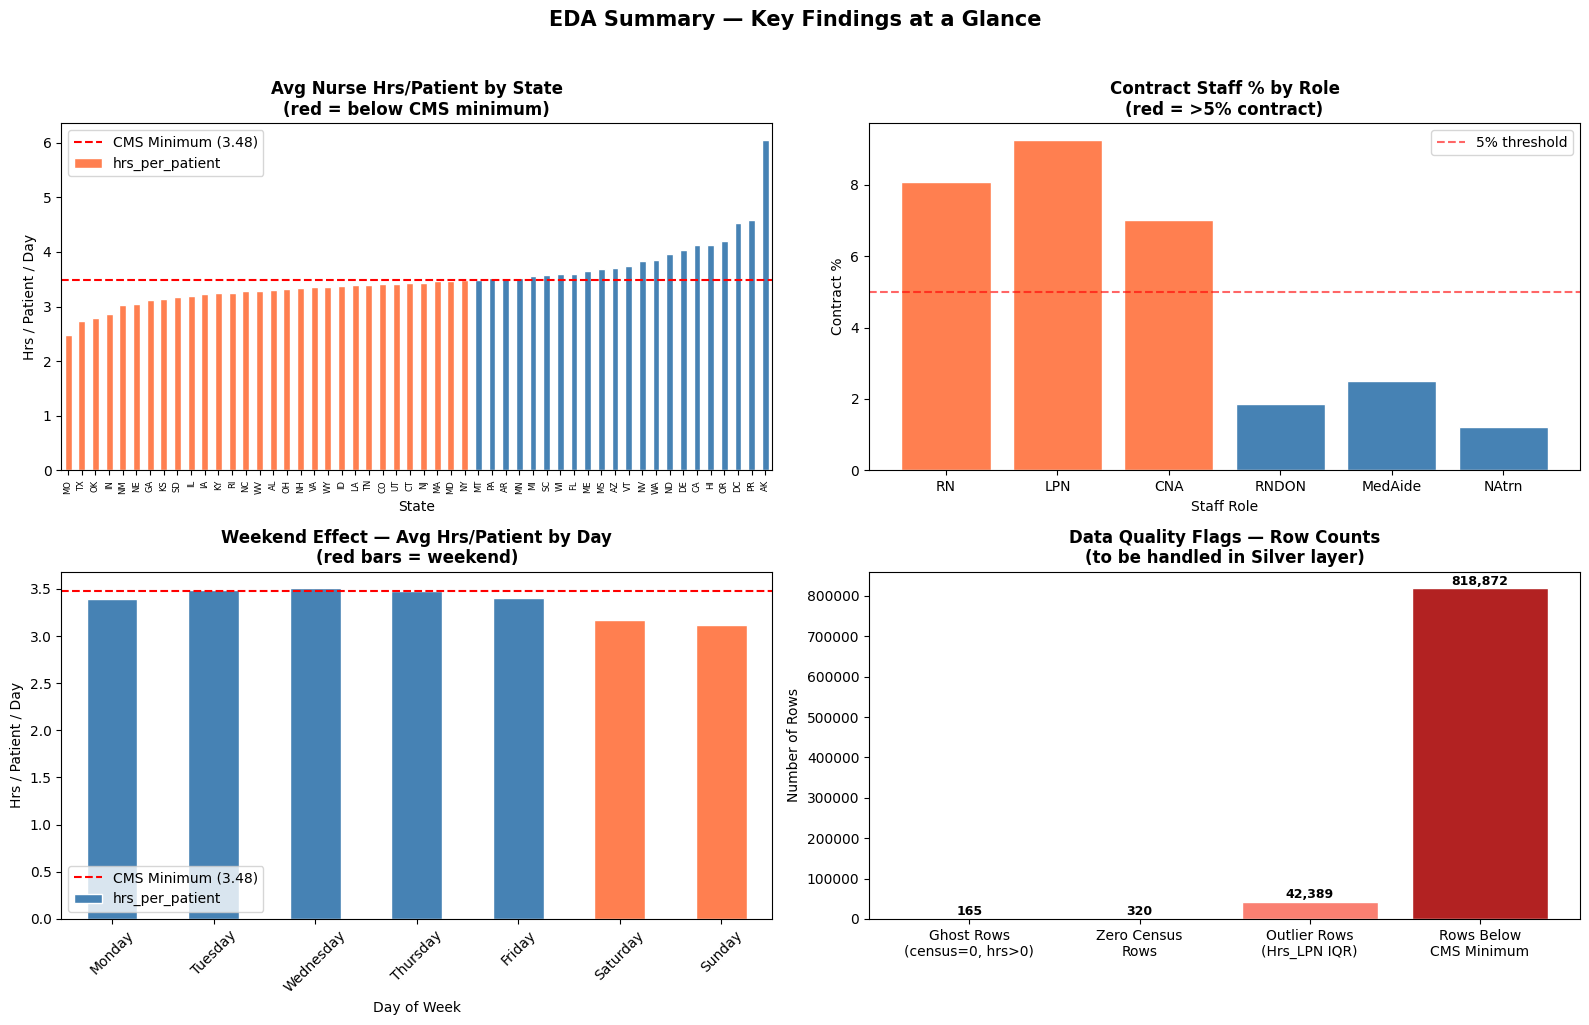

Summary chart saved to docs/eda_summary.png


In [216]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA Summary — Key Findings at a Glance',
             fontsize=15, fontweight='bold', y=1.02)

# ── Chart 1: CMS Compliance by State ─────────────────────────────────────────
df_valid = df[df['MDScensus'] > 0].copy()
df_valid['total_nursing_hrs'] = df_valid['Hrs_RN'] + df_valid['Hrs_LPN'] + df_valid['Hrs_CNA']
df_valid['hrs_per_patient']   = df_valid['total_nursing_hrs'] / df_valid['MDScensus']

cms_minimum = 3.48
state_ratio = df_valid.groupby('STATE')['hrs_per_patient'].mean().sort_values()
colors      = ['coral' if x < cms_minimum else 'steelblue' for x in state_ratio.values]

state_ratio.plot(kind='bar', ax=axes[0,0], color=colors, edgecolor='white')
axes[0,0].axhline(y=cms_minimum, color='red', linestyle='--',
                   linewidth=1.5, label=f'CMS Minimum ({cms_minimum})')
axes[0,0].set_title('Avg Nurse Hrs/Patient by State\n(red = below CMS minimum)',
                     fontweight='bold')
axes[0,0].set_xlabel('State')
axes[0,0].set_ylabel('Hrs / Patient / Day')
axes[0,0].tick_params(axis='x', rotation=90, labelsize=6)
axes[0,0].legend()

# ── Chart 2: Contract % by Role ───────────────────────────────────────────────
roles        = ['RN', 'LPN', 'CNA', 'RNDON', 'MedAide', 'NAtrn']
contract_pct = [8.08, 9.27, 7.01, 1.86, 2.51, 1.21]
bar_colors   = ['coral' if p > 5 else 'steelblue' for p in contract_pct]

axes[0,1].bar(roles, contract_pct, color=bar_colors, edgecolor='white')
axes[0,1].axhline(y=5, color='red', linestyle='--',
                   alpha=0.6, label='5% threshold')
axes[0,1].set_title('Contract Staff % by Role\n(red = >5% contract)',
                     fontweight='bold')
axes[0,1].set_ylabel('Contract %')
axes[0,1].set_xlabel('Staff Role')
axes[0,1].legend()

# ── Chart 3: Weekend Effect ───────────────────────────────────────────────────
df['work_date']   = pd.to_datetime(df['WorkDate'].astype(str), format='%Y%m%d')
df['day_of_week'] = df['work_date'].dt.day_name()
df['is_weekend']  = df['work_date'].dt.dayofweek >= 5

df_valid2 = df[df['MDScensus'] > 0].copy()
df_valid2['total_nursing_hrs'] = (df_valid2['Hrs_RN'] +
                                   df_valid2['Hrs_LPN'] +
                                   df_valid2['Hrs_CNA'])
df_valid2['hrs_per_patient'] = df_valid2['total_nursing_hrs'] / df_valid2['MDScensus']

day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg    = (df_valid2.groupby('day_of_week')['hrs_per_patient']
                       .mean()
                       .reindex(day_order))
day_colors = ['coral' if d in ['Saturday','Sunday'] else 'steelblue'
              for d in day_order]

day_avg.plot(kind='bar', ax=axes[1,0], color=day_colors, edgecolor='white')
axes[1,0].axhline(y=cms_minimum, color='red', linestyle='--',
                   linewidth=1.5, label=f'CMS Minimum ({cms_minimum})')
axes[1,0].set_title('Weekend Effect — Avg Hrs/Patient by Day\n(red bars = weekend)',
                     fontweight='bold')
axes[1,0].set_ylabel('Hrs / Patient / Day')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# ── Chart 4: Data Quality Flags Summary ───────────────────────────────────────
hrs_cols  = [c for c in df.columns if c.startswith('Hrs_')]
hrs_total = df[hrs_cols].sum(axis=1)

quality_labels = [
    'Ghost Rows\n(census=0, hrs>0)',
    'Zero Census\nRows',
    'Outlier Rows\n(Hrs_LPN IQR)',
    'Rows Below\nCMS Minimum'
]

ghost_count   = len(df[(df['MDScensus'] == 0) & (hrs_total > 0)])
zero_census   = (df['MDScensus'] == 0).sum()
lpn_q3        = df['Hrs_LPN'].quantile(0.75)
lpn_iqr       = lpn_q3 - df['Hrs_LPN'].quantile(0.25)
outlier_count = (df['Hrs_LPN'] > lpn_q3 + 1.5 * lpn_iqr).sum()
below_cms     = (df_valid['hrs_per_patient'] < cms_minimum).sum()

quality_counts = [ghost_count, zero_census, outlier_count, below_cms]
bar_colors2    = ['coral', 'orange', 'salmon', 'firebrick']

bars = axes[1,1].bar(quality_labels, quality_counts,
                      color=bar_colors2, edgecolor='white')
axes[1,1].set_title('Data Quality Flags — Row Counts\n(to be handled in Silver layer)',
                     fontweight='bold')
axes[1,1].set_ylabel('Number of Rows')

for bar, count in zip(bars, quality_counts):
    axes[1,1].text(bar.get_x() + bar.get_width()/2.,
                   bar.get_height() + 1000,
                   f'{count:,}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary chart saved to docs/eda_summary.png")